**Trading Strategy:- RSI (14) + 200 EMA + SL/Target**

RSI (14) measures momentum using the last 14 candles and helps identify overbought and oversold conditions

Risk Reward Ratio:- 1:2

**Install & Import Required Libraries**

In [ ]:
# Install required libraries
!pip install yfinance ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=858235380ad61e9b56c293dada08a5b47bf5e3cd207939e4d5432c8480865439
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
# Import libraries
import yfinance as yf              # For stock data
import pandas as pd                # Data handling
import numpy as np                 # Numerical operations
import matplotlib.pyplot as plt    # Plotting
from ta.momentum import RSIIndicator
from ta.trend import EMAIndicator


**Download Indian Stock Data (NSE)**

In [ ]:
# Define stock symbol (NSE format)
symbol = "RELIANCE.NS"

# Download historical data
data = yf.download(symbol, start="2018-01-01", end="2025-01-01")

# Display first few rows
data.head()


/tmp/ipython-input-954832703.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start="2018-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2018-01-01,401.864807,407.585208,400.870911,407.585208,9453202
2018-01-02,402.483215,406.193768,400.384994,403.300424,9499419
2018-01-03,404.095520,409.042914,403.322483,408.601166,13507800
2018-01-04,406.525055,407.187662,404.493091,405.575331,9008932
2018-01-05,407.828156,409.440487,406.502971,407.187664,7441284


**Calculate RSI (14) and 200 EMA**

Adds RSI (14) and EMA (200) indicators to the dataset.

In [ ]:
# Ensure Close is 1D Series
close_prices = data['Close'].squeeze()

# Calculate RSI (14)
rsi = RSIIndicator(close=close_prices, window=14)
data['RSI'] = rsi.rsi()

# Calculate EMA (200)
ema = EMAIndicator(close=close_prices, window=200)
data['EMA_200'] = ema.ema_indicator()

# Drop missing values
data.dropna(inplace=True)

data.tail()



Price,Close,High,Low,Open,Volume,RSI,EMA_200
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,
Date,,,,,,,
2024-12-24,1217.885864,1228.642950,1216.142826,1217.437703,6734917,36.696166,1367.893489
2024-12-26,1211.710571,1222.816119,1209.419672,1219.379892,10016178,35.496975,1366.339430
2024-12-27,1216.192749,1223.015476,1212.158811,1213.453688,7000397,37.103582,1364.845434
2024-12-30,1205.883789,1218.334064,1203.294156,1211.561187,8818766,34.947543,1363.263726
2024-12-31,1210.614868,1214.250373,1201.351937,1203.194553,6405475,36.763634,1361.744832


**Define Strategy Parameters,**
**Sets capital, risk, stop-loss, and target values.**

In [ ]:
# Strategy parameters
initial_capital = 100000        # ₹1,00,000
capital = initial_capital
risk_per_trade = 0.01           # 1% risk
stop_loss_pct = 0.02            # 2% stop loss
target_pct = 0.04               # 4% target

# Tracking variables
position = 0
entry_price = 0
equity_curve = []

# Trade tracking
trades = []
wins = 0
losses = 0

**Generate Buy & Sell Signals + Backtesting Logic**

Backtesting Loop (BUY / SELL LOGIC)

In [ ]:
# Flatten columns if they are multi-index
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)


In [ ]:
# Simulates trades based on RSI + EMA rules and updates capital.

# =========================
#  BACKTESTING LOOP
# =========================

for i in range(1, len(data)):

    # Extract scalar values
    price = data['Close'].iloc[i].item()
    rsi_today = data['RSI'].iloc[i].item()
    rsi_yesterday = data['RSI'].iloc[i-1].item()
    ema_200 = data['EMA_200'].iloc[i].item()

    # -----------------
    # BUY CONDITION
    # -----------------
    if position == 0:
        if price > ema_200 and rsi_yesterday < 35 and rsi_today > 35:

            risk_amount = capital * risk_per_trade
            stop_loss = price * (1 - stop_loss_pct)
            risk_per_share = price - stop_loss
            quantity = risk_amount / risk_per_share

            entry_price = price
            target_price = price * (1 + target_pct)
            position = quantity

    # -----------------
    # EXIT CONDITION
    # -----------------
    elif position > 0:
        if price <= stop_loss or price >= target_price or rsi_today > 70:

            pnl = (price - entry_price) * position
            capital += pnl

            # Record trade result
            trades.append(pnl)
            if pnl > 0:
                wins += 1
            else:
                losses += 1

            position = 0

    # Track equity daily
    equity_curve.append(capital)


In [ ]:
if position == 0 and price > ema_200 and rsi_yesterday < 35 and rsi_today > 35:
    print(f"BUY at {price} on {data.index[i]}")
elif position > 0 and (price <= stop_loss or price >= target_price or rsi_today > 70):
    print(f"SELL at {price} on {data.index[i]} | PnL: {(price - entry_price)*position:.2f}")


**Create Equity Curve Data**

Stores equity values over time for plotting and analysis.

In [ ]:
# Convert equity curve to DataFrame

equity_df = pd.DataFrame({
    'Date': data.index[:len(equity_curve)],
    'Equity': equity_curve
})

equity_df.set_index('Date', inplace=True)

equity_df.tail()

,Equity
Date,
2024-12-23,105477.970002
2024-12-24,105477.970002
2024-12-26,105477.970002
2024-12-27,105477.970002
2024-12-30,105477.970002


**Performance Metrics**

Calculates total return and CAGR.

In [ ]:
# Total return
total_return = (capital - initial_capital) / initial_capital * 100

# CAGR
years = (equity_df.index[-1] - equity_df.index[0]).days / 365
cagr = ((capital / initial_capital) ** (1 / years) - 1) * 100

print(f"Total Return: {total_return:.2f}%")
print(f"CAGR: {cagr:.2f}%")


Total Return: 5.48%
CAGR: 0.87%


**WIN RATE**

In [ ]:
total_trades = wins + losses
win_rate = (wins / total_trades) * 100 if total_trades > 0 else 0

print(f"Total Trades: {total_trades}")
print(f"Win Rate: {win_rate:.2f}%")


Total Trades: 10
Win Rate: 60.00%


**MAX DRAWDOWN**

In [ ]:
equity_df['Peak'] = equity_df['Equity'].cummax()
equity_df['Drawdown'] = (equity_df['Equity'] - equity_df['Peak']) / equity_df['Peak']

max_drawdown = equity_df['Drawdown'].min() * 100
print(f"Max Drawdown: {max_drawdown:.2f}%")


Max Drawdown: -4.31%


**SHARPE RATIO**

In [ ]:
equity_df['Returns'] = equity_df['Equity'].pct_change().dropna()

sharpe_ratio = (equity_df['Returns'].mean() / equity_df['Returns'].std()) * np.sqrt(252)
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")


Sharpe Ratio: 0.31


**Plot Equity Curve**


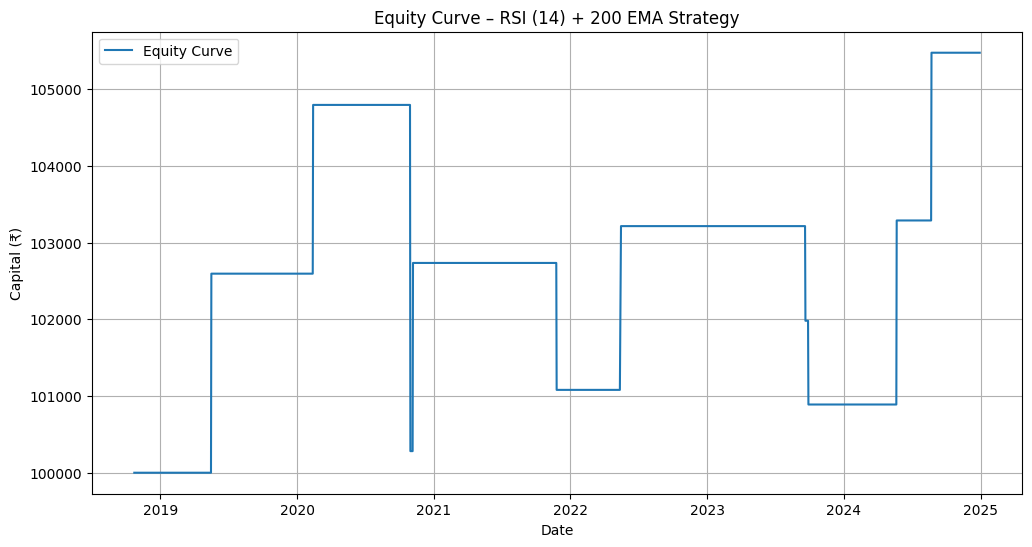

In [ ]:
# Visualizes strategy growth over time.

# =========================
# CELL 8: PLOT EQUITY CURVE
# =========================

plt.figure(figsize=(12, 6))

plt.plot(equity_df.index, equity_df['Equity'], label='Equity Curve')

plt.title('Equity Curve – RSI (14) + 200 EMA Strategy')
plt.xlabel('Date')
plt.ylabel('Capital (₹)')
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
# Final capital
final_capital = equity_curve[-1]

# Total profit/loss
total_pnl = final_capital - initial_capital

print(f"Initial Capital: ₹{initial_capital:.2f}")
print(f"Final Capital: ₹{final_capital:.2f}")
print(f"Total P&L: ₹{total_pnl:.2f}")


Initial Capital: ₹100000.00
Final Capital: ₹105477.97
Total P&L: ₹5477.97


Cell 1 → Data + Indicators

Cell 2 → Parameters + Tracking

Cell 3 → Backtest loop

Cell 4 → Equity DataFrame

Cell 5 → Win rate

Cell 6 → Max drawdown

Cell 7 → Sharpe ratio

Cell 8 → Plot
